###  Time Series and Category Sales Analysis

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,date,category,region,channel,units,unit_price,discount,sales
0,2023-01-01,Electronics,Dhaka,Online,3,10745.30,0.054,28572.05
1,2023-01-01,Electronics,Dhaka,Online,1,9812.28,0.096,8504.26
2,2023-01-01,Electronics,Chattogram,Online,1,17528.49,0.100,14349.23
3,2023-01-01,Electronics,Khulna,Online,1,10703.45,0.127,8588.57
4,2023-01-01,Electronics,Dhaka,Store,1,10847.32,0.080,10799.74


In [24]:
df.shape

(23851, 8)

In [25]:
df.isnull().sum()

date          0
category      0
region        0
channel       0
units         0
unit_price    0
discount      0
sales         0
dtype: int64

In [26]:
df.describe(include="all")

,date,category,region,channel,units,unit_price,discount,sales
count,23851,23851,23851,23851,23851.000000,23851.000000,23851.000000,23851.000000
unique,731,5,4,2,NaN,NaN,NaN,NaN
top,2023-12-10,Fashion,Dhaka,Online,NaN,NaN,NaN,NaN
freq,57,6316,9554,13906,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.969100,4248.532714,0.081007,8852.453832
std,NaN,NaN,NaN,NaN,1.158728,3747.461660,0.047336,11027.048972
min,NaN,NaN,NaN,NaN,1.000000,504.230000,0.000000,556.360000
25%,NaN,NaN,NaN,NaN,1.000000,1814.660000,0.046000,2822.015000
50%,NaN,NaN,NaN,NaN,2.000000,2750.960000,0.080000,4876.980000
75%,NaN,NaN,NaN,NaN,3.000000,4455.090000,0.114000,10201.260000


In [27]:
df.duplicated().sum()

0

* Fix date type

In [28]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23851 entries, 0 to 23850
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        23851 non-null  datetime64[ns]
 1   category    23851 non-null  object        
 2   region      23851 non-null  object        
 3   channel     23851 non-null  object        
 4   units       23851 non-null  int64         
 5   unit_price  23851 non-null  float64       
 6   discount    23851 non-null  float64       
 7   sales       23851 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 1.5+ MB


In [30]:
df.head()

,date,category,region,channel,units,unit_price,discount,sales
0,2023-01-01,Electronics,Dhaka,Online,3,10745.30,0.054,28572.05
1,2023-01-01,Electronics,Dhaka,Online,1,9812.28,0.096,8504.26
2,2023-01-01,Electronics,Chattogram,Online,1,17528.49,0.100,14349.23
3,2023-01-01,Electronics,Khulna,Online,1,10703.45,0.127,8588.57
4,2023-01-01,Electronics,Dhaka,Store,1,10847.32,0.080,10799.74


In [35]:
df = df.drop_duplicates()

df = df.dropna(subset=["date", "category", "region", "sales", "units"])

df = df[(df["sales"] > 0) & (df["units"] > 0)]

In [37]:
df["Month"] = df["date"].dt.month
df["Year"] = df["date"].dt.year

In [38]:
df.head()

,date,category,region,channel,units,unit_price,discount,sales,Month,Year
0,2023-01-01,Electronics,Dhaka,Online,3,10745.30,0.054,28572.05,1,2023
1,2023-01-01,Electronics,Dhaka,Online,1,9812.28,0.096,8504.26,1,2023
2,2023-01-01,Electronics,Chattogram,Online,1,17528.49,0.100,14349.23,1,2023
3,2023-01-01,Electronics,Khulna,Online,1,10703.45,0.127,8588.57,1,2023
4,2023-01-01,Electronics,Dhaka,Store,1,10847.32,0.080,10799.74,1,2023


* Daily Sales Trend

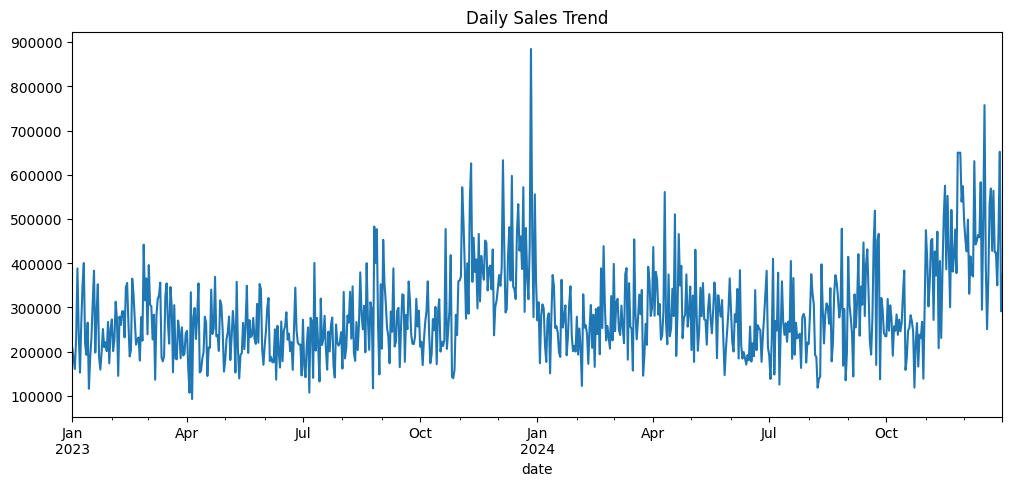

In [41]:
daily = df.groupby("date")["sales"].sum()

daily.plot(figsize=(12,5), title="Daily Sales Trend")
plt.show()

* Monthly + Quarterly Sales

C:\Users\Asus\AppData\Local\Temp\ipykernel_13616\2119034309.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.Grouper(key="date", freq="M"))["sales"].sum()
C:\Users\Asus\AppData\Local\Temp\ipykernel_13616\2119034309.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df.groupby(pd.Grouper(key="date", freq="Q"))["sales"].sum()


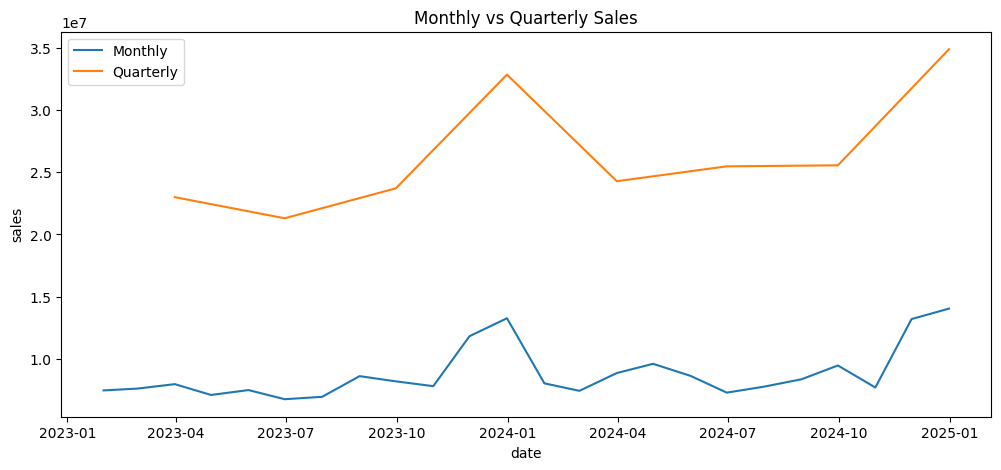

In [54]:
monthly = df.groupby(pd.Grouper(key="date", freq="M"))["sales"].sum()
quarterly = df.groupby(pd.Grouper(key="date", freq="Q"))["sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly, label="Monthly")
plt.plot(quarterly, label="Quarterly")

plt.title("Monthly vs Quarterly Sales")
plt.xlabel("date")
plt.ylabel("sales")
plt.legend()

plt.show()

* Monthly Aggregation

C:\Users\Asus\AppData\Local\Temp\ipykernel_13616\2699800180.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.Grouper(key="date", freq="M"))["sales"].sum()


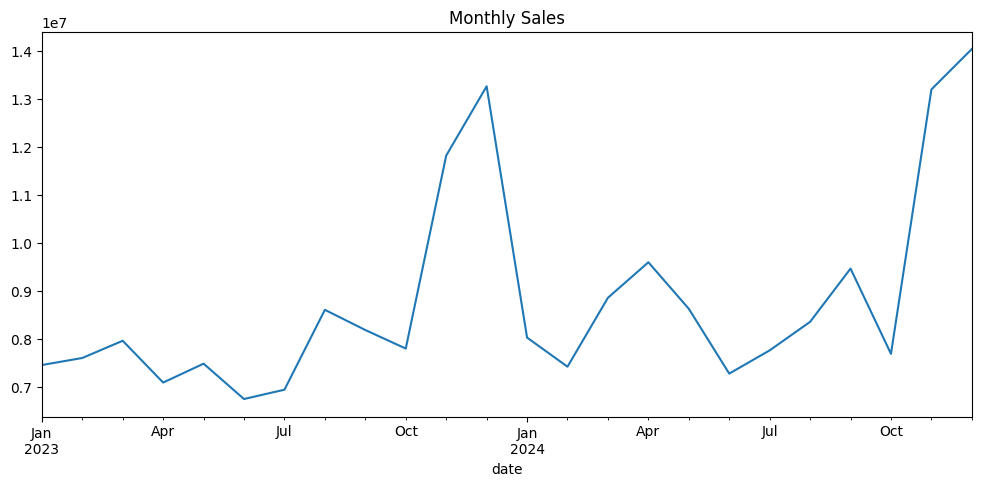

In [44]:
monthly = df.groupby(pd.Grouper(key="date", freq="M"))["sales"].sum()

monthly.plot(figsize=(12,5), title="Monthly Sales")
plt.show()

* Category Bar Chart

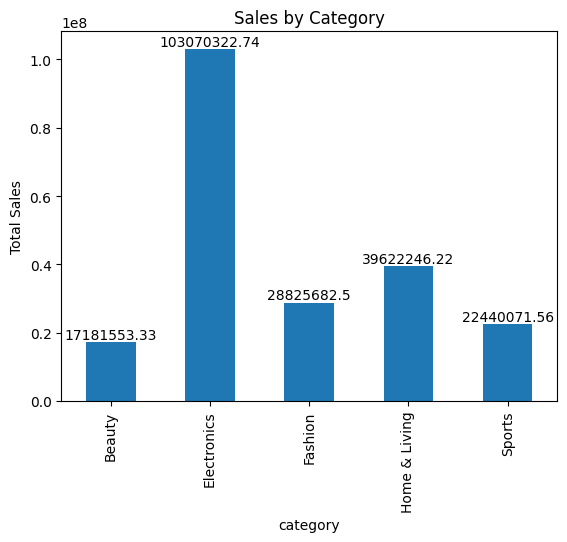

In [56]:
cat = df.groupby("category")["sales"].sum()

ax = cat.plot(kind="bar", title="Sales by Category")
ax.set_ylabel("Total Sales")

for i, v in enumerate(cat):
    ax.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.savefig("bar.png", dpi=300)

* pie chart

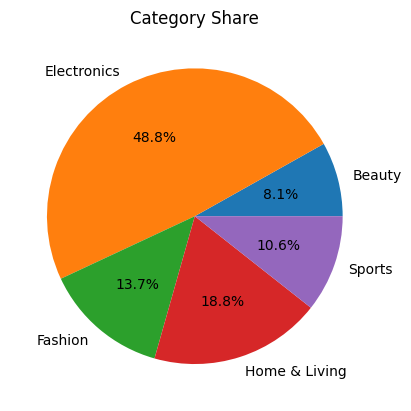

In [49]:
cat.plot(kind="pie", autopct="%1.1f%%")
plt.title("Category Share")
plt.ylabel("")
plt.show()

Sales show an increasing trend over time.
Monthly aggregation reveals seasonal variation.
Electronics category contributes the highest sales.
Pie chart shows the distribution of sales across categories.